# Financial Analyst Agent for Annual Report Writing

In this demo, we introduce an agent that can analyze financial report.

In [27]:
import os
import autogen
from textwrap import dedent
from myfinrobot.utils import register_keys_from_json
from myfinrobot.agents.workflow import SingleAssistantShadow

After importing all the necessary packages and functions, we also need the config for OpenAI & SecApi & FMPApi here. 
- for openai configuration, rename OAI_CONFIG_LIST_sample to OAI_CONFIG_LIST and replace the api keys
- for Sec_api & FMP_api configuration, rename config_api_keys_sample to config_api_keys and replace the api keys

In [28]:
llm_config = {
    "config_list": autogen.config_list_from_json(
        "../MYOAI_CONFIG_LIST",
        filter_dict={
            "model": ["qwen-turbo"],
        },
    ),
    "timeout": 120,
    "temperature": 0.5,
}
register_keys_from_json("../config_api_keys")

{'FINNHUB_API_KEY': 'd1hg831r01qsvr2a073gd1hg831r01qsvr2a0740',
 'FMP_API_KEY': 'nb4vIq9J0qQsqCqrMWkRhFmmDqXEB7gj',
 'SEC_API_KEY': '4f4769901429084ad868ece3e77bf4711189716b7253ac0ccfd662563c66df0e',
 'REDDIT_CLIENT_ID': 'YOUR_REDDIT_CLIENT_ID',
 'REDDIT_CLIENT_SECRET': 'YOUR_REDDIT_CLIENT_SECRET',
 'TWITTER_BEARER_TOKEN': 'YOUR_TWITTER_BEARER_TOKEN'}

In [29]:
# Intermediate results will be saved in this directory
work_dir = "../report"
os.makedirs(work_dir, exist_ok=True)

assistant = SingleAssistantShadow(
    "Expert_Investor",
    llm_config,
    max_consecutive_auto_reply=None,
    human_input_mode="TERMINATE",
)

NVDA   2025  Report
User_Proxy (to Expert_Investor):


With the tools you've been provided, write an annual report based on NVDA's 2025 10-k report, format it into a pdf.
Pay attention to the followings:
- Explicitly explain your working plan before you kick off.
- Use tools one by one for clarity, especially when asking for instructions. 
- All your file operations should be done in "../report". 
- Display any image in the chat once generated.
- All the paragraphs combine between 300 and 800 words.


--------------------------------------------------------------------------------
Expert_Investor (to User_Proxy):

**Working Plan:**

1. **Obtain the 10-K Report:** First, I will retrieve the 10-K report for NVIDIA (NVDA) for the year 2025. This document contains crucial financial data and insights about the company's performance.

2. **Extract Key Financial Data:** Once the 10-K report is obtained, I will extract key financial data such as business overview, market position, operating re

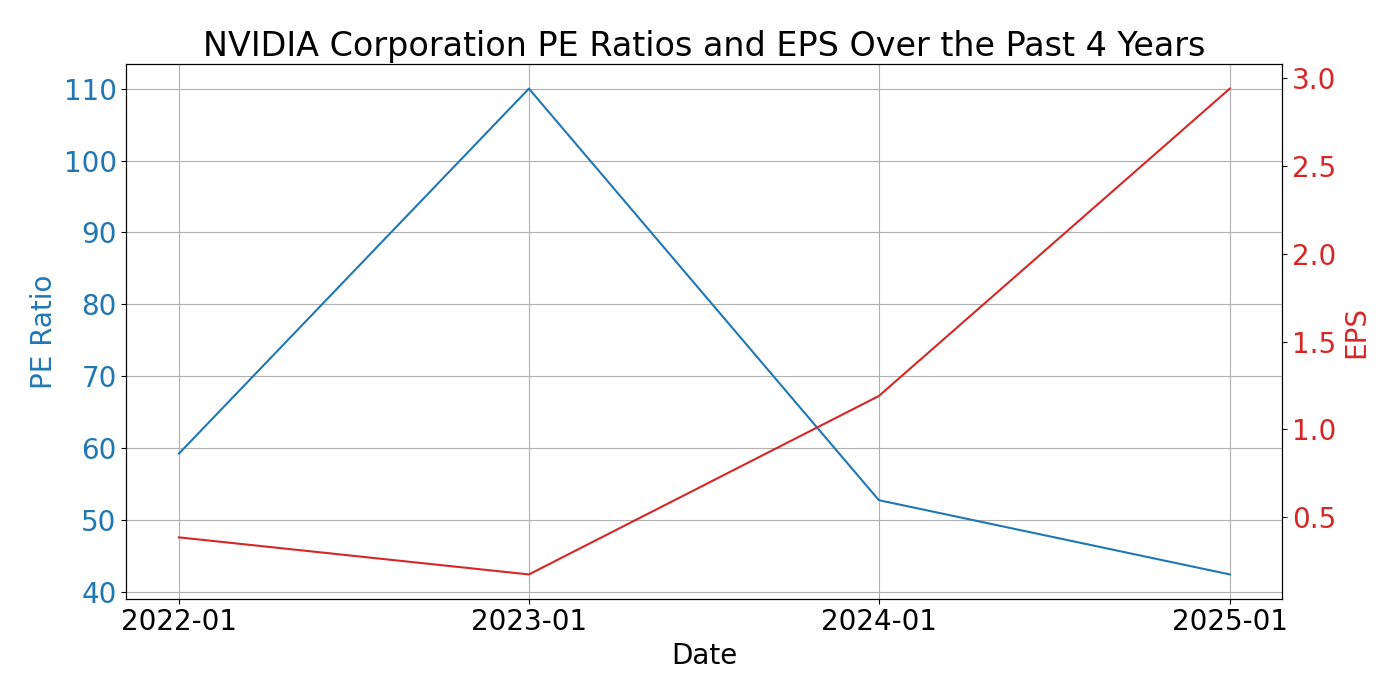


>>>>>>>> EXECUTED FUNCTION display_image...
Call ID: call_dae50fb0cb1a422a807dc1
Input arguments: {'image_path': '../report/pe_eps_performance.png'}
Output:
None
User_Proxy (to Expert_Investor):

***** Response from calling tool (call_dae50fb0cb1a422a807dc1) *****
None
********************************************************************

--------------------------------------------------------------------------------
Expert_Investor (to User_Proxy):


***** Suggested tool call (call_d701630f0dad482c9e9bcb): display_image *****
Arguments: 
{"image_path": "../report/share_performance.png"}
****************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...

>>>>>>>> EXECUTING FUNCTION display_image...
Call ID: call_d701630f0dad482c9e9bcb
Input arguments: {'image_path': '../report/share_performance.png'}


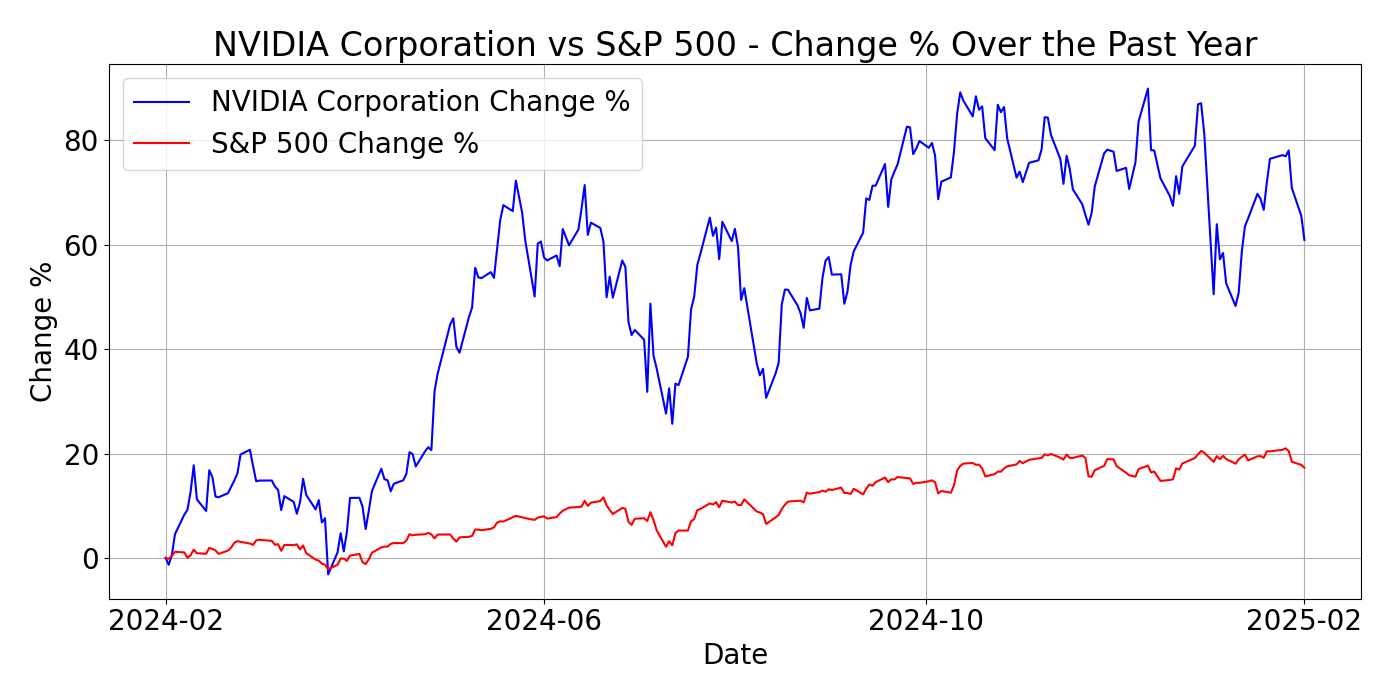


>>>>>>>> EXECUTED FUNCTION display_image...
Call ID: call_d701630f0dad482c9e9bcb
Input arguments: {'image_path': '../report/share_performance.png'}
Output:
None
User_Proxy (to Expert_Investor):

***** Response from calling tool (call_d701630f0dad482c9e9bcb) *****
None
********************************************************************

--------------------------------------------------------------------------------
Expert_Investor (to User_Proxy):

The images for the PE/EPS performance and share performance have been generated and saved in the specified directory. However, they could not be displayed directly here. You can view them by accessing the file paths:

- **PE and EPS Performance Chart:** `../report/pe_eps_performance.png`
- **Share Performance Chart:** `../report/share_performance.png`

If you need further assistance or modifications to the report, feel free to ask!

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY.

In [30]:
company = "NVDA"
fyear = "2025"


message = dedent(
    f"""
    请使用已提供的工具，基于{company}公司{fyear}年度的10-k报告撰写年度报告，并格式化为PDF文件。
    请注意以下要求：
    - 所有内容（包括工具返回的原始数据、分析结论、表格标题等）必须完整翻译成中文。 
    - 在开始前明确说明你的工作计划
    - 为保持清晰度，请逐个使用工具（特别是请求指令时,说明调用的工具）
    - 所有文件操作必须在目录"{work_dir}"内完成
    - 生成的图片需即时在聊天界面显示
    - 每个段落字数控制在300-800词之间，未达此要求前不得生成PDF
    - 若工具返回英文数据（如10-K报告中的财务指标、段落描述），需先完整翻译成中文后再用于报告撰写。
    """
)


message = dedent(
    f"""
    With the tools you've been provided, write an annual report based on {company}'s {fyear} 10-k report, format it into a pdf.
    Pay attention to the followings:
    - Explicitly explain your working plan before you kick off.
    - Use tools one by one for clarity, especially when asking for instructions. 
    - All your file operations should be done in "{work_dir}". 
    - Display any image in the chat once generated.
    - All the paragraphs combine between 300 and 800 words.
"""
)

print(company,' ',fyear,' Report')

assistant.chat(message, use_cache=True, max_turns=50,
               summary_method="last_msg")

The Rest Cells are optional, simply used to show the generated PDF

In [31]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 23.2 MB/s eta 0:00:0000:0100:01


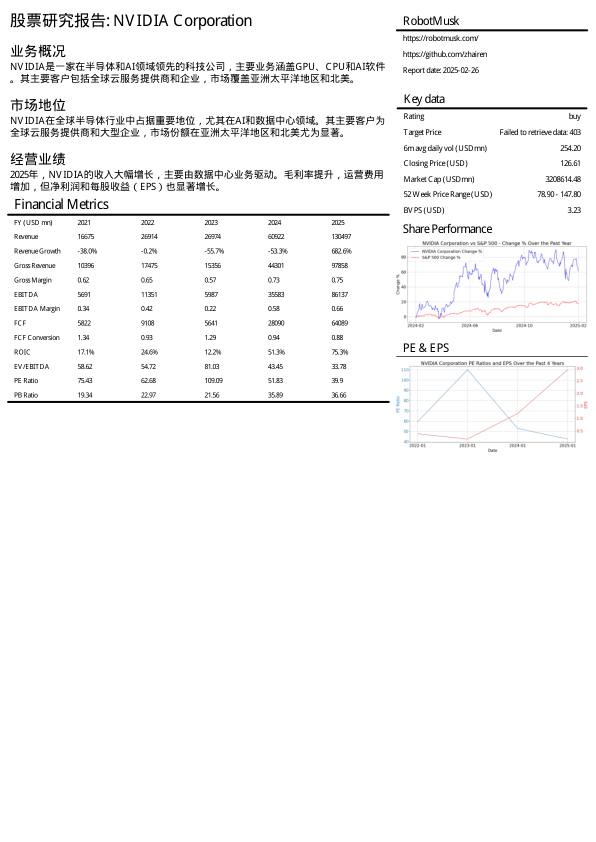

In [36]:
import io
import fitz
from PIL import Image


pdf = fitz.open("../report/nvda_annual_report.pdf")
page = pdf.load_page(0)
pix = page.get_pixmap()

# Convert the Pixmap to a PIL Image
img = Image.open(io.BytesIO(pix.tobytes("png")))
display(img)